In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import zipfile
#import warnings
#warnings.filterwarnings('ignore')

from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
from sklearn.mixture import GaussianMixture

random.seed(2718281)
np.random.seed(2718281)


## In this module you will learn how to:

1. Use dimensionality reduction to visualize high dimensional data.
2. Examine principal components analysis on shopping cart data
3. Explore clustering algorithms like K-means and Gaussian Mixture Models (GMM)

## The Data

In this example we will use a sample of the InstaCart shopping dataset. This data is incredibly sparse (there are many more zeros than ones), as such we will only use the top 5,000 active users and the 997 most popular products.

Any given row in the data frame refers to whether that individual purchased a product represented in the column or not.


In [2]:
import os
import urllib.request
if not os.path.exists('Choice_Mat.zip'):
    urllib.request.urlretrieve("https://github.com/bquistorff/NABE_workbooks/raw/colab/Choice_Mat.zip", 'Choice_Mat.zip')

In [3]:
with zipfile.ZipFile('Choice_Mat.zip', 'r') as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        choices = pd.read_csv(f)

# Remove zero-variance columns (equivalent to: choices[which(apply(choices,2,var)!=0)])
choices = choices.loc[:, choices.var() != 0]

# Reads csv files into Python
print(choices.iloc[:5, -8:].to_string())
# Examine the last few columns of the first rows

print(f'\nDataset dimensions: {choices.shape}')
# Returns the dimension of the dataset


   992  993  994  995  996  997  998  999
0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  0.0
1  0.0  0.0  0.0  0.0  1.0  0.0  0.0  1.0
2  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
4  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0

Dataset dimensions: (5000, 997)


## Visualization

When the data is binary we can visualize the entire data frame using a heatmap. This will work for count data as well, so long as the counts aren't too variable. The heatmap shows us what items are most popular by including a black cell where that item was purchased by an individual.


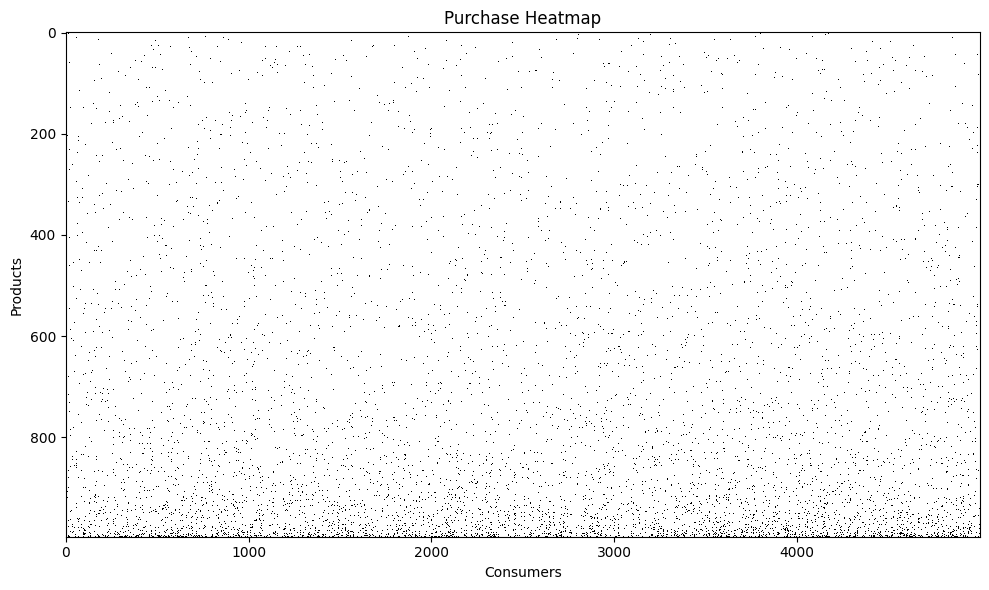

In [4]:
# Equivalent to: image(t(as.matrix(choices)), col=gray.colors(2,start=1,end=0), axes=FALSE)
# Transpose so rows=products, cols=consumers; binary colormap: white=0, black=1
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(choices.values.T, aspect='auto', cmap='binary', interpolation='none')
ax.set_xlabel('Consumers')
ax.set_ylabel('Products')
ax.set_title('Purchase Heatmap')
plt.tight_layout()
plt.show()


The data is sorted based on the popularity, as one will observe from the density there is long tail behavior in the product purchases.

## PCA

Our goal with dimensionality reduction is to find some inherent structure in this high dimensional data that can be exploited in our further analysis. The oldest and most widely used method to do this is to use PCA (principal components analysis). Recall that PCA produces a low-dimensional linear representation of a dataset, by finding directions of maximal variance that are mutually orthogonal.

We use `TruncatedSVD` (no centering) to replicate R's `prcomp(choices, center=FALSE)`. Standard `sklearn.PCA` always centers the data first, which would change the result.


In [5]:
X = choices.values.astype(float)

# TruncatedSVD does NOT center — equivalent to prcomp(choices, center=FALSE)
# We compute enough components for downstream use (projection + scree plot)
n_components = min(50, X.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=2718281)
svd.fit(X)
# svd.components_ has shape (n_components, n_features)
# Each row is a principal component direction — equivalent to pca$rotation columns in R


TruncatedSVD(n_components=50, random_state=2718281)

## Visualizing the PCA Embedding Space

For visualization purposes we want to look at the data in 2 dimensions. To do this we can project the data onto the space corresponding to the first two principal components. `svd.components_[:2].T` is the loading matrix (equivalent to R's `pca$rotation[,1:2]`).


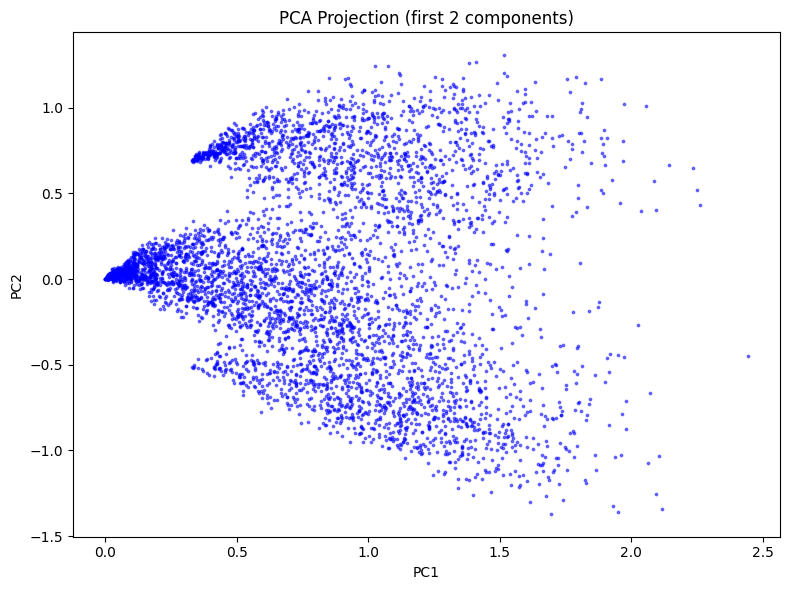

In [6]:
# R: project = pca$rotation[,1:2];  project = data.frame(as.matrix(choices) %*% project)
# Python equivalent: X @ svd.components_[:2].T
rotation   = svd.components_.T          # shape (n_features, n_components) = pca$rotation
project    = X @ rotation[:, :2]        # shape (n_obs, 2)  — project into 2 dimensions
project_df = pd.DataFrame(project, columns=['PC1', 'PC2'])

plt.figure(figsize=(8, 6))
plt.scatter(project_df['PC1'], project_df['PC2'], color='blue', s=3, alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (first 2 components)')
plt.tight_layout()
plt.show()


## Clustering

These clusters aren't necessarily the most well defined, but there appears to be some sort of structure to the data. We don't want to arbitrarily assign groups based on visual inspection, so using a clustering algorithm on this lower dimensional representation is a good idea. There are many clustering algorithms to choose from. Some of the most common are Gaussian Mixture Models (GMM) and K-Means.

In addition to choosing the clustering algorithm one typically selects the number of clusters. Let's look at GMM and K-Means where the optimal number of clusters is chosen through cross-validation based on the Silhouette Coefficient (a measure of cluster separation and tightness).


In [7]:
def closest_cluster(x, centers):
    """Assign point x to the nearest cluster center (equivalent to R's closest.cluster)."""
    dists = np.sqrt(((centers - x) ** 2).sum(axis=1))
    return np.argmin(dists)

# This is the same cross-validation logic as Module 1,
# but with a clustering algorithm instead of OLS

num_clust = 10
num_folds = 5
project_mat = project_df.values          # (5000, 2) numpy array
n           = len(project_mat)
size        = round(n / num_folds)       # 1000 rows per fold

# sil[fold, k] — stores mean silhouette; column 0 and 1 left as NaN (loop starts at k=2)
sil = np.full((num_folds, num_clust + 1), np.nan)

for j in range(2, num_clust + 1):
    for i in range(num_folds):
        # Fold assignment — equivalent to R's kronecker-based indexing
        test_idx  = np.arange(i * size, (i + 1) * size)
        train_idx = np.concatenate([
            np.arange(0, i * size),
            np.arange((i + 1) * size, num_folds * size)
        ])

        train_data = project_mat[train_idx]
        test_data  = project_mat[test_idx]

        # K-means on training data (nstart=10 → n_init=10; iter.max=100 → max_iter=100)
        km = KMeans(n_clusters=j, n_init=10, max_iter=100, random_state=2718281)
        km.fit(train_data)

        # Assign each test point to the nearest training cluster center
        test_clusters = np.array([
            closest_cluster(x, km.cluster_centers_) for x in test_data
        ])

        # Silhouette on test data (equivalent to: silhouette(clusters, dist(test_tmp)))
        if len(np.unique(test_clusters)) > 1:
            sil_vals   = silhouette_samples(test_data, test_clusters)
            sil[i, j]  = sil_vals.mean()


In [8]:
# which.min(colMeans(sil)) — find k with the lowest mean silhouette across folds
col_means = np.nanmean(sil, axis=0)   # mean over folds for each k (index = k)
best_k    = int(np.nanargmin(col_means))   # matches R's which.min; col 0&1 are NaN
print(f'Lowest Silhouette achieved with {best_k} Clusters')


Lowest Silhouette achieved with 9 Clusters


/tmp/ipykernel_2017/2670806737.py:2: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(sil, axis=0)   # mean over folds for each k (index = k)


## What do we find?

According to the silhouette metric and the k-means algorithm the "best" number of clusters to use is 9. In this case we can interpret this as 9 different consumer types in our data set.

Now that we have optimized let's see what these clusters look like.


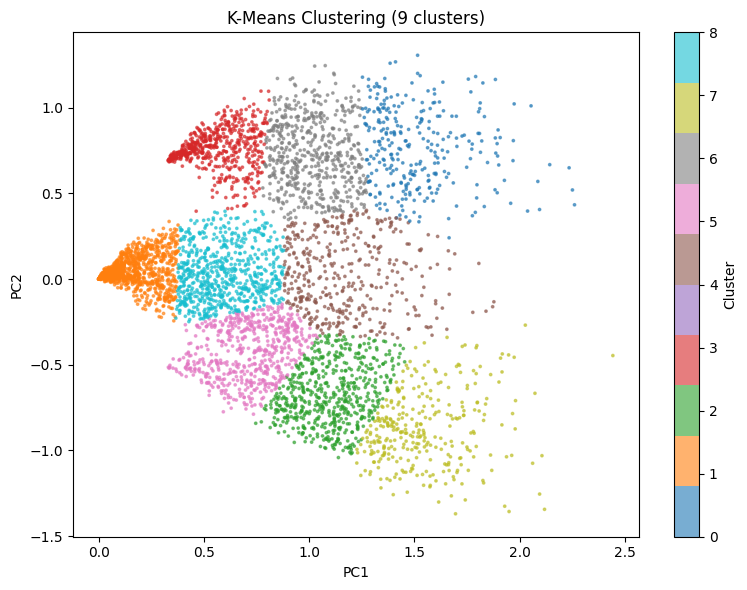

In [9]:
# Fit K-means with the selected number of clusters on the full projection
km_final = KMeans(n_clusters=best_k, n_init=10, max_iter=100, random_state=2718281)
km_final.fit(project_df.values)
cluster_labels = km_final.labels_   # equivalent to km$cluster

plt.figure(figsize=(8, 6))
scatter = plt.scatter(project_df['PC1'], project_df['PC2'],
                      c=cluster_labels, cmap='tab10', s=3, alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means Clustering ({best_k} clusters)')
plt.tight_layout()
plt.show()


## Examination of Clusters

I don't think we would have chosen these clusters if we were simply eyeballing them. This makes things a bit tricky to interpret. Let's try a different clustering algorithm and see if the results are robust.

## Gaussian Mixture Model

The GMM clustering algorithm works similarly to the k-means algorithm except it attempts to fit $k$ normal distributions to the points using the EM algorithm. Once the number of mixtures is known, the algorithm will find the mean and covariance of each mixture.

In Python we use `sklearn.mixture.GaussianMixture`. We try all four covariance types (`full`, `tied`, `diag`, `spherical`) across G = 1–9 components and select the best model by BIC — the Python equivalent of R's `Mclust`.

**Note on BIC convention:** `sklearn` uses the standard BIC where *lower is better* (`BIC = -2·logL + k·log(n)`). R's `mclust` uses the opposite sign — *higher is better*. The selected model is identical; only the sign of the printed values differs.


In [10]:
# Equivalent to: gmm = Mclust(project)
# Mclust tries 14 covariance structures × G=1:9; we use sklearn's 4 covariance types

covariance_types = ['full', 'tied', 'diag', 'spherical']
max_G = 9

bic_results = {}   # (cov_type, G) -> sklearn BIC (lower = better)
gmm_models  = {}   # (cov_type, G) -> fitted GaussianMixture

for cov_type in covariance_types:
    for G in range(1, max_G + 1):
        gm = GaussianMixture(n_components=G, covariance_type=cov_type,
                             n_init=3, max_iter=200, random_state=2718281)
        gm.fit(project_df.values)
        bic_results[(cov_type, G)] = gm.bic(project_df.values)
        gmm_models[(cov_type, G)]  = gm

# Best model: minimum sklearn BIC (= maximum mclust BIC)
best_gmm_key              = min(bic_results, key=bic_results.get)
best_gmm_cov, best_gmm_G  = best_gmm_key
gmm                       = gmm_models[best_gmm_key]
print(f'Best GMM: G={best_gmm_G} components, covariance_type="{best_gmm_cov}"')


Best GMM: G=8 components, covariance_type="full"


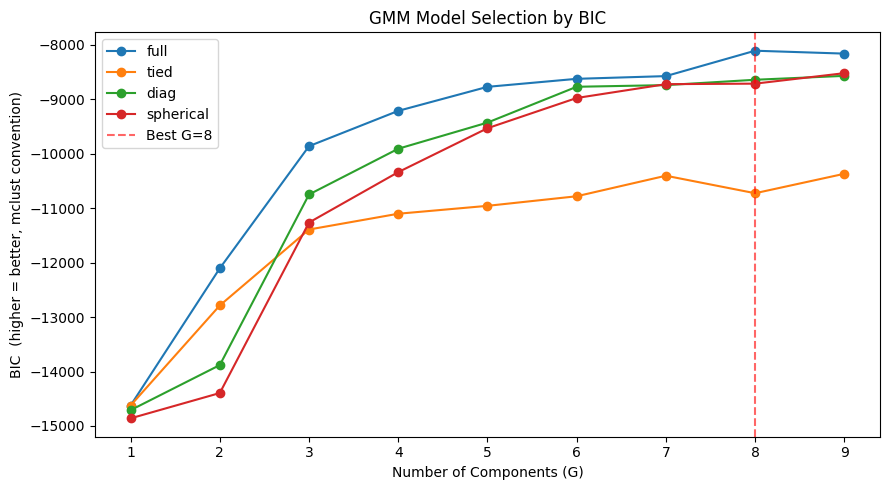

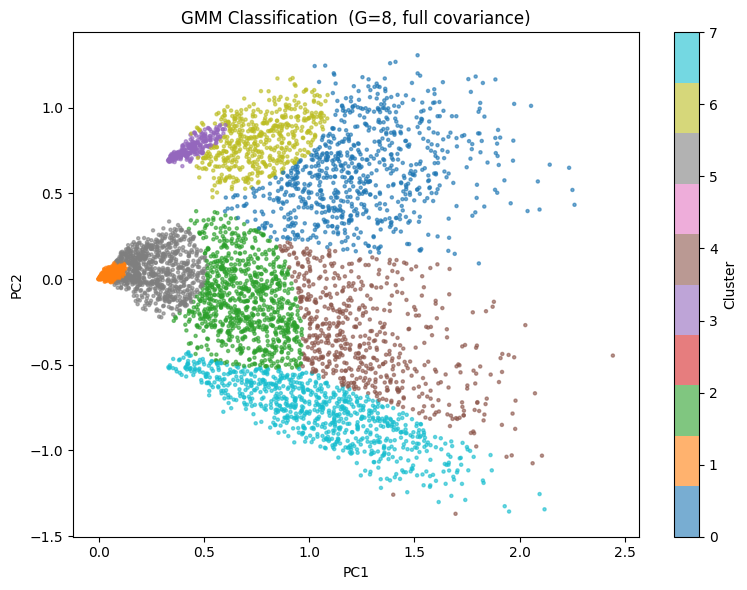

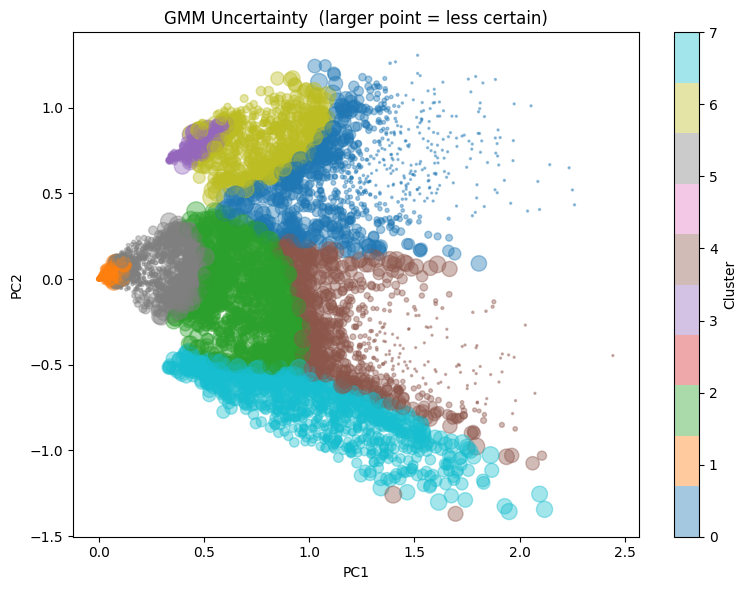

Bayesian Information Criterion (higher = better, mclust convention):
        full     tied     diag  spherical
G=1 -14623.9 -14623.9 -14709.3   -14859.6
G=2 -12103.4 -12786.2 -13881.4   -14394.8
G=3  -9860.2 -11391.3 -10747.6   -11263.0
G=4  -9212.0 -11101.5  -9907.8   -10337.2
G=5  -8770.7 -10956.5  -9427.4    -9530.9
G=6  -8623.6 -10780.5  -8769.4    -8975.7
G=7  -8573.6 -10403.4  -8739.2    -8721.7
G=8  -8107.2 -10724.8  -8640.8    -8712.0
G=9  -8160.4 -10367.8  -8569.1    -8519.8

Best model: G=8, covariance_type="full"


In [11]:
# ── Plot 1: BIC by covariance type and G (equivalent to plot(gmm) BIC panel) ──
fig, ax = plt.subplots(figsize=(9, 5))
for cov_type in covariance_types:
    Gs   = range(1, max_G + 1)
    bics = [-bic_results[(cov_type, G)] for G in Gs]   # flip sign to match mclust (higher=better)
    ax.plot(Gs, bics, marker='o', label=cov_type)
ax.axvline(best_gmm_G, color='red', ls='--', alpha=0.6, label=f'Best G={best_gmm_G}')
ax.set_xlabel('Number of Components (G)')
ax.set_ylabel('BIC  (higher = better, mclust convention)')
ax.set_title('GMM Model Selection by BIC')
ax.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: Classification — scatter colored by cluster assignment ─────────────
labels      = gmm.predict(project_df.values)
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(project_df['PC1'], project_df['PC2'],
                c=labels, cmap='tab10', s=5, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Cluster')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'GMM Classification  (G={best_gmm_G}, {best_gmm_cov} covariance)')
plt.tight_layout()
plt.show()

# ── Plot 3: Uncertainty — point size ∝ (1 − max posterior probability) ─────────
probs       = gmm.predict_proba(project_df.values)
uncertainty = 1 - probs.max(axis=1)
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(project_df['PC1'], project_df['PC2'],
                c=labels, cmap='tab10',
                s=np.clip(uncertainty * 300, 2, 300), alpha=0.4)
plt.colorbar(sc, ax=ax, label='Cluster')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('GMM Uncertainty  (larger point = less certain)')
plt.tight_layout()
plt.show()

# ── BIC table (equivalent to gmm$BIC) — mclust convention (higher = better) ───
bic_table = pd.DataFrame(
    index=[f'G={G}' for G in range(1, max_G + 1)],
    columns=covariance_types,
    dtype=float
)
for cov_type in covariance_types:
    for G in range(1, max_G + 1):
        bic_table.loc[f'G={G}', cov_type] = -bic_results[(cov_type, G)]   # flip to mclust sign
print('Bayesian Information Criterion (higher = better, mclust convention):')
print(bic_table.to_string(float_format='{:.1f}'.format))
print(f'\nBest model: G={best_gmm_G}, covariance_type="{best_gmm_cov}"')


## Examination of GMM

Our results are robust in terms of the number of clusters. The GMM clustering algorithm also chooses 9 clusters, but assignment is not identical. One thing that is nice about GMM is that you get a measure of uncertainty when you compute cluster assignment. You can see that there is quite a bit of uncertainty in this result (the larger circles are more uncertain). This occurs because the groups do not have a lot of separation.

## Scree Plot

Recall that we used a two-dimensional projection so that we could visualize our data easily. However, this choice may not be "optimal" in the sense of maximizing the variation in the data without losing too much information. We can determine an "optimal" dimensionality reduction by looking at the scree plot (the magnitude of the ordered eigenvalues).


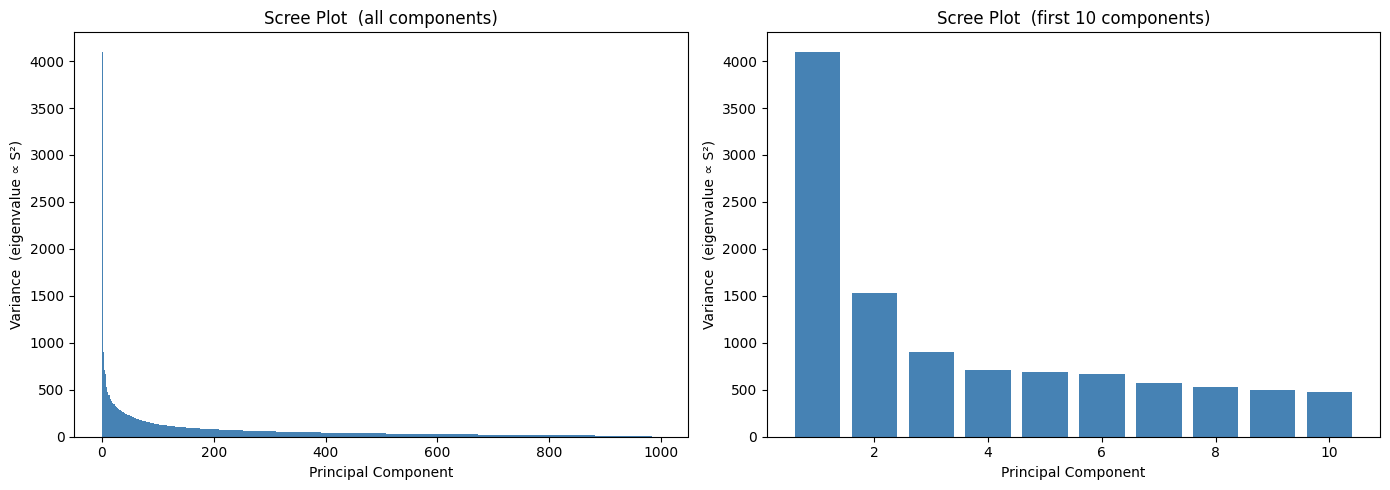

In [12]:
# Compute all singular values for the full scree plot
# np.linalg.svd with compute_uv=False returns only S (the singular values), efficient
# Eigenvalues (variance) are proportional to S²
# Equivalent to: screeplot(pca, npcs=1000) and screeplot(pca, npcs=10)

S_all        = np.linalg.svd(X, compute_uv=False)    # all min(n,p) singular values
eigenvalues  = S_all ** 2                              # proportional to explained variance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full scree plot (all components)
axes[0].bar(range(1, len(eigenvalues) + 1), eigenvalues,
            color='steelblue', width=1.0, linewidth=0)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance  (eigenvalue ∝ S²)')
axes[0].set_title('Scree Plot  (all components)')

# Zoom: first 10 components
axes[1].bar(range(1, 11), eigenvalues[:10], color='steelblue')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance  (eigenvalue ∝ S²)')
axes[1].set_title('Scree Plot  (first 10 components)')

plt.tight_layout()
plt.show()


## Examination of Scree Plot

The first image shows the scree plot for all of the eigenvalues and the second for only the first 10. In the first case there are simply too many points to examine. When we zoom in on the first 10 ordered eigenvalues we see that a lot of the variation is explained by only a few components. Even so, we may want to re-run those clustering algorithms on projections based on 3 or 4 eigenvalues to evaluate the robustness of our results.


\
## Exercise

In this module we saw how to visualize high dimensional discrete data using a heatmap. We \
learned how to use PCA to project our high-dimensional data onto a two-dimensional surface. \
This procedure allowed us to visualize the variation in the data based on the first two \
eigenvalues. Given this projection we used two different clustering algorithms K-means and \
GMM to find the optimal number of clusters according to the silhouette metric for k-means \
and BIC for GMM. Finally we showed how a scree plot can help determine the "optimal" \
dimensionality reduction. We may also want to compute the principal components using the \
correlation matrix.

1. Using `sklearn.PCA` you can compute PCA using the correlation matrix by passing \
`StandardScaler`-transformed data (equivalent to R's `prcomp(scale=TRUE)`)
2. Project onto the two dimensional surface. Does it look different?
3. Run GMM on this embedding space. Is the optimal number of clusters different?
